In [27]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [31]:
bscan=np.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/training_bscan/2026_03_26_cfrp_multiple_fbh_gauss_heat_5s_30s_45W_multiple_fbh_001_row_0200_bscan.npy",allow_pickle=True)
mask=np.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/training_mask/2026_03_26_cfrp_multiple_fbh_gauss_heat_5s_30s_45W_multiple_fbh_001_row_0200_mask.npy",allow_pickle=True)

bscan.shape,mask.shape

((1754, 512), (512,))

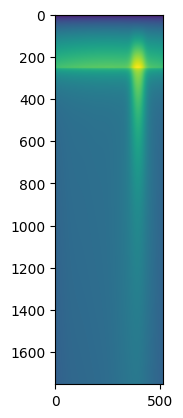

In [34]:
plt.imshow(bscan)

In [25]:
sample=np.load('/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/training/2026_03_26_cfrp_multiple_fbh_gauss_heat_5s_30s_45W_multiple_fbh_010.npz',allow_pickle=True)
data=sample['data']
mask=sample['mask']

In [26]:
sample['meta']

array([['time', '28/03/2026 16:28:31'],
       ['lamp_power', 45],
       ['lamp_power_units', 'W'],
       ['T1', 4],
       ['T1_units', 'frames'],
       ['T2', 250],
       ['T2_units', 'frames'],
       ['T3', 1500],
       ['T3_units', 'frames'],
       ['fps', 50.0],
       ['fps_units', 'frames/s'],
       ['height', 512],
       ['height_units', 'pixels'],
       ['width', 512],
       ['width_units', 'pixels'],
       ['sequence_length', 1754],
       ['sequence_length_units', 'frames'],
       ['working_distance', 200.0],
       ['working_distance_units', 'mm'],
       ['thickness', 0.0035],
       ['thickness_units', 'm'],
       ['size_X', 0.1],
       ['size_X_units', 'm'],
       ['size_Y', 0.1],
       ['size_Y_units', 'm'],
       ['thermal_conductivity_x', 2.23],
       ['thermal_conductivity_x_units', 'W/(m·K)'],
       ['thermal_conductivity_y', 1.95],
       ['thermal_conductivity_y_units', 'W/(m·K)'],
       ['thermal_conductivity_z', 0.93],
       ['thermal_condu

Text(0, 0.5, 'Height of sample [px]')

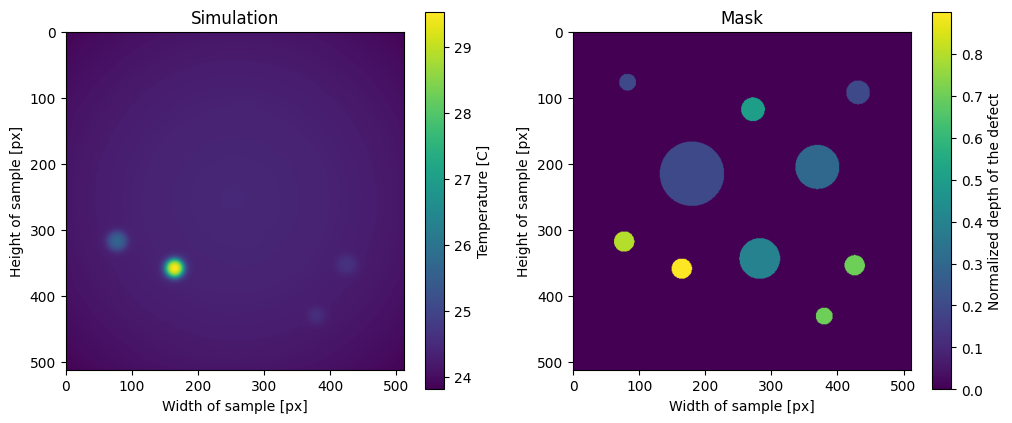

In [5]:
plt.figure(figsize=(12,7))
plt.subplot(1,2,1)
plt.imshow(data[50,:,:])
plt.title('Simulation')
plt.colorbar(label='Temperature [C]',shrink=0.7)
plt.xlabel('Width of sample [px]')
plt.ylabel('Height of sample [px]')
plt.subplot(1,2,2)
plt.imshow(mask)
plt.title('Mask')
plt.colorbar(label='Normalized depth of the defect',shrink=0.7)
plt.xlabel('Width of sample [px]')
plt.ylabel('Height of sample [px]')

In [6]:
bfft=np.fft.fft(data[254:,200,:],axis=0)

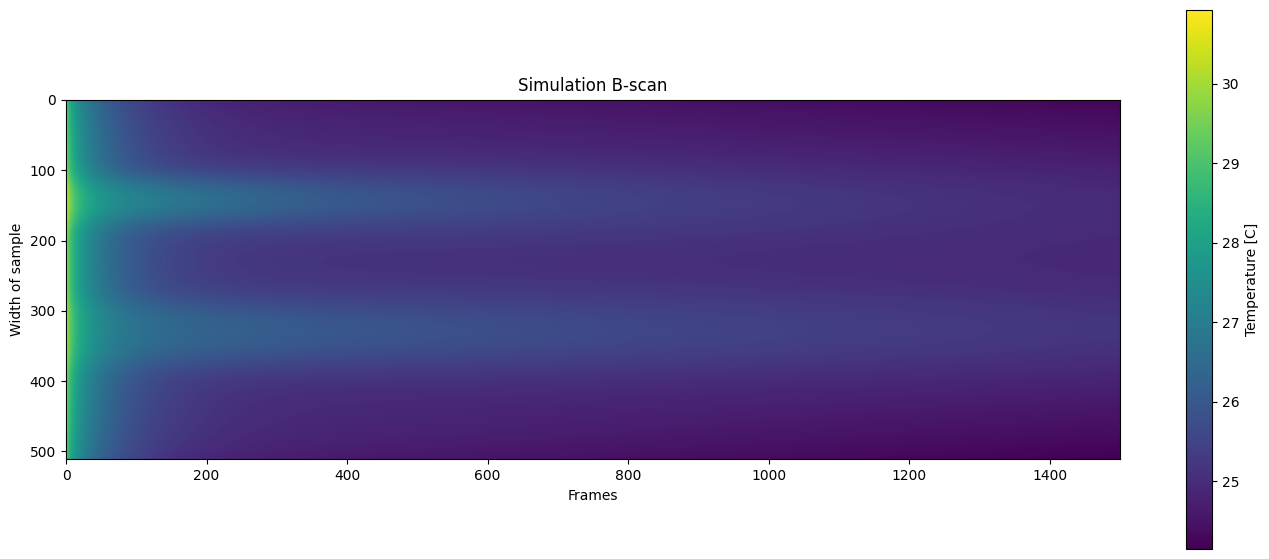

In [145]:
plt.figure(figsize=(17,10))
plt.imshow(np.rot90(data[254:,200,:]))
plt.title('Simulation B-scan')
plt.xlabel('Frames')
plt.ylabel('Width of sample')
plt.colorbar(label='Temperature [C]',shrink=0.7)

(0.0, 100.0)

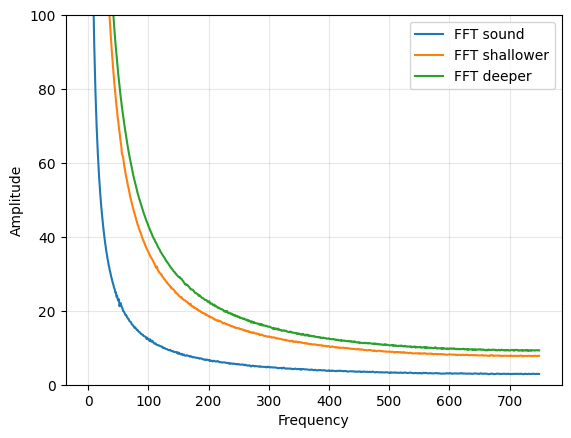

In [133]:
plt.plot((np.abs(bfft[:750,100])),label='FFT sound')
plt.plot((np.abs(bfft[:750,250])),label='FFT shallower')
plt.plot((np.abs(bfft[:750,400])),label='FFT deeper')
plt.grid(alpha=0.3)
plt.legend()
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.ylim(0,100)

Text(0, 0.5, 'Amplitude')

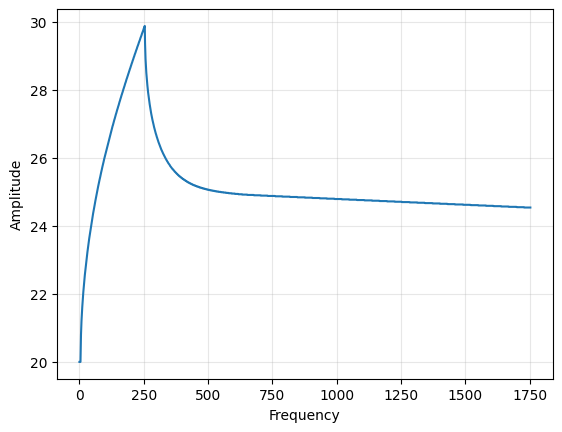

In [10]:
plt.plot(data[:,100,100])
plt.grid(alpha=0.3)
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
